Demo of Laplacian Eigenmaps Implementation and Circular Pseudotime Calculation

In [3]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import pandas as pd
from sklearn.neighbors import kneighbors_graph
import matplotlib.pyplot as plt

In [4]:
def laplacianEigenmaps(CSR, nComponents = 2):
    """Input Parameters:
    CSR: compressed sparse row matrix of cell-cell similarity graph
    nComponents: number of embedding dimensions = 2 to get 2D embedding coordinates per cell required for circular pseudotime calculation

    Computes graph Laplacian from cell-cell similarity CSR matrix
    and solves eigenproblem to get 2 smallest non-trivial eigenvalues for embeddings

    Output:
    embedding: shape (nCells, nComponents)
    eigenvalues: shape (nComponents)"""

    # degree matrix -- sum of similarities for each cell (degree of each node in graph) along diagonal of sparse diagonal matrix
    degrees = np.array(CSR.sum(axis = 1)).flatten()
    D = sp.diags(degrees, format = 'csr')

    # graph laplacian L = D - W where W = CSR
    L = D - CSR

    # solution to eigenproblem Lv = lamda(Dv)
    # requesting "SM" for smallest eigvas/vecs and k = 3 to get smallest 2 non-trivial outputs (smallest eigval will be trivial = 0)
    eigvals, eigvecs = eigsh(L, k = nComponents + 1, M = D, which = "SM", tol = 1e-6)

    # sorting eigenvalues in ascending order
    ordered = np.argsort(eigvals)
    eigvals = eigvals[ordered]
    eigvecs = eigvecs[:,ordered]

    # dropping trivial eigenvector
    embedding = eigvecs[:, 1:]
    eigvals = eigvals[1:]

    return embedding, eigvals

In [5]:
def pseudotime(embedding):

    # converts embedding from 2D coordinates to angular coordinates
    pseudo = np.arctan2(embedding[:, 1], embedding[:, 0])

    return pseudo

In [6]:
# loading in concentric circle toy datasets to test functions
set1 = "../data/toy_datasets/circle_0.05noise.csv"
set2 = "../data/toy_datasets/circle_0.2noise.csv"
set3 = "../data/toy_datasets/circle_0.5noise.csv"

def loadData(sets):
    X = []
    labels = []
    for s in sets:
        df = pd.read_csv(s)
        x = df[["x", "y"]].values
        label = df["target"].values
        X.append(x)
        labels.append(label)
    return X, labels

datasets, labels = loadData([set1, set2, set3])

In [7]:
def testLaplacian(datasets, labels):

    noiseLevels = ["0.05 noise", "0.2 noise", "0.5 noise"]
    pseudotimes = []

    fig, axes = plt.subplots(3, 4, figsize = (15, 4 * len(datasets)))

    for i, (data, label) in enumerate(zip(datasets, labels)):

        # using only one of the circles in the dataset to make results more interpretable
        data = data[label == 0]
        label = label[label == 0]

        # making toydata sets into similarity graph to convert into weighted matrix
        W = kneighbors_graph(data, n_neighbors = 10, mode = "connectivity", include_self = False)
        W = (W + W.T) / 2

        embedding, eigvals = laplacianEigenmaps(W)
        pseudo = pseudotime(embedding)
        pseudotimes.append(pseudo)

        # plotting raw circle data
        axes[i, 0].scatter(data[:, 0], data[:, 1], c = label, cmap = "coolwarm", s = 10)
        axes[i, 0].set_title(f"Raw Data ({noiseLevels[i]})")

        # plotting embedding
        axes[i, 1].scatter(embedding[:, 0], embedding[:, 1], c = label, cmap = "coolwarm", s = 10)
        axes[i, 1].set_title(f"Embedding ({noiseLevels[i]})")

        # plotting pseudotime
        axes[i, 2].scatter(embedding[:, 0], embedding[:, 1], c = pseudo, cmap = "hsv", s = 10)
        axes[i, 2].set_title(f"Pseudotime ({noiseLevels[i]})")

        # plotting true angles from raw toydata sets and comparing to derived pseudotimes
        # should be well-formed diagonal lines
        trueAngle = np.arctan2(data[:, 1], data[:, 0])
        axes[i, 3].scatter(trueAngle, pseudo, c = label, cmap = "coolwarm", s = 10)
        axes[i, 3].set_xlabel("True Angle")
        axes[i, 3].set_ylabel("Pseudotime")
        axes[i, 3].set_title(f"True Angle vs. Pseudotime Angle ({noiseLevels[i]})")

    plt.tight_layout()
    plt.show()


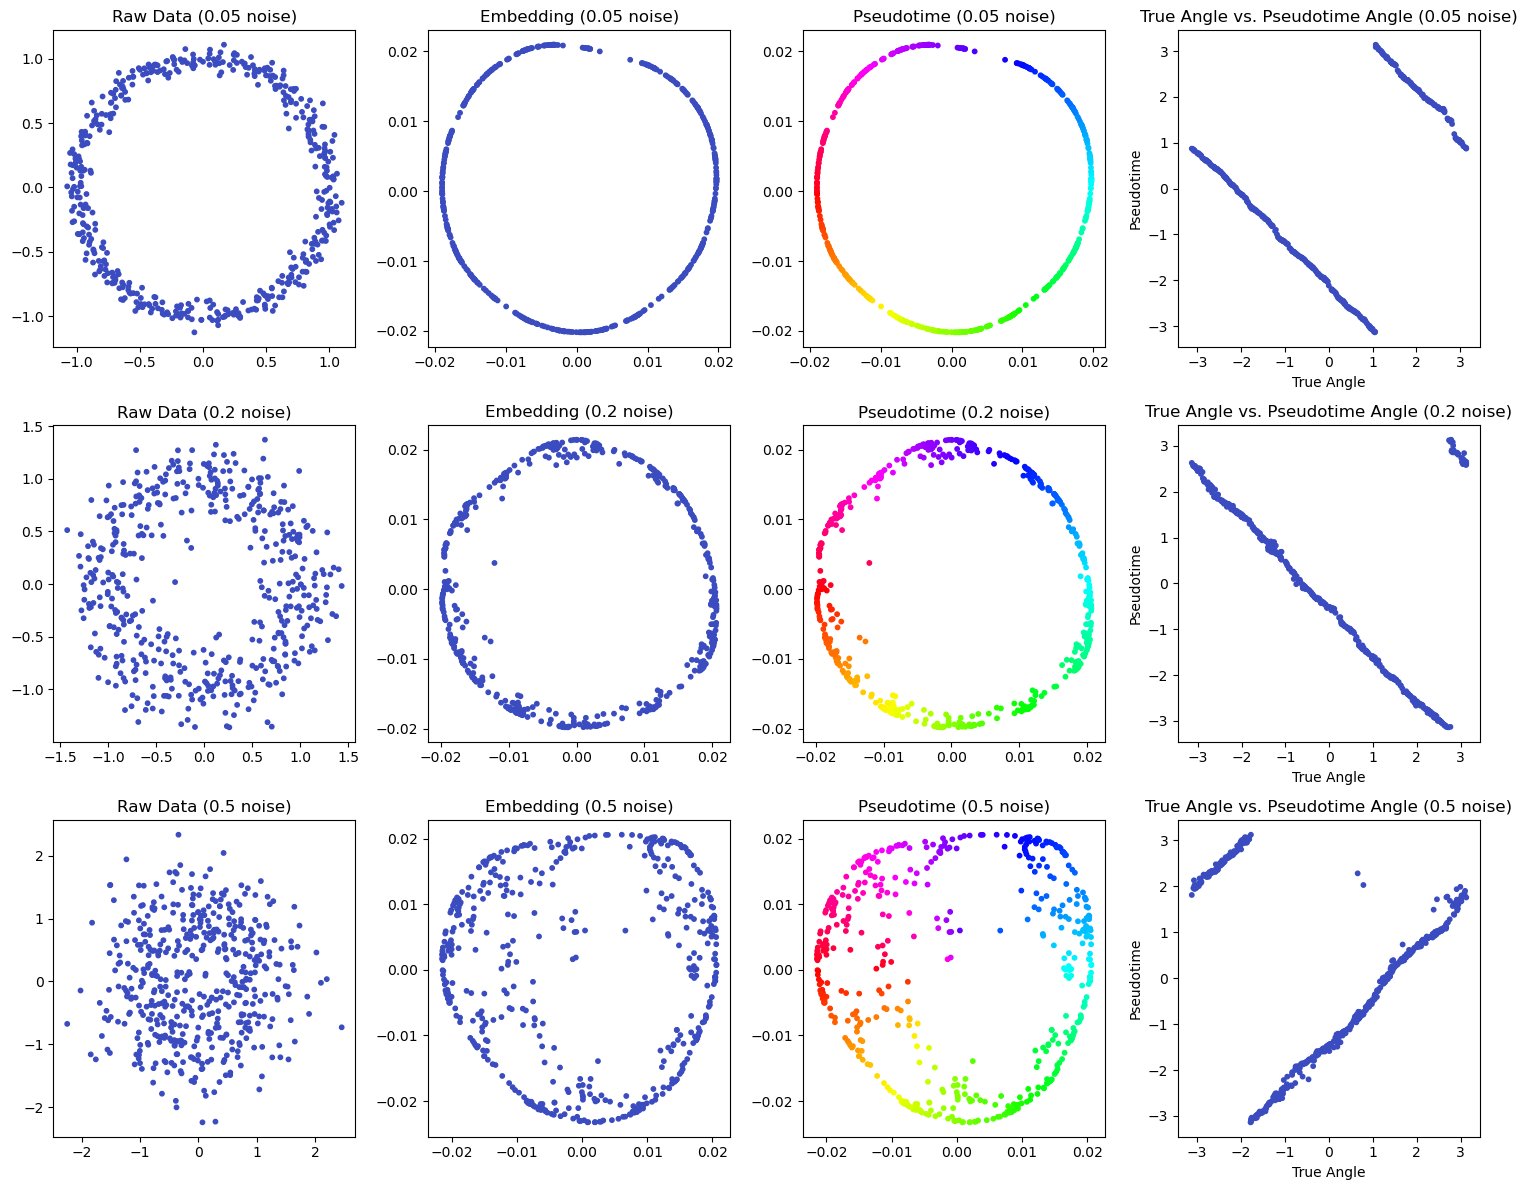

In [8]:
testLaplacian(datasets, labels)